In [1]:
# %matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from collections import OrderedDict
import astropy.units as u
import math

import multiprocessing as mul

from pyLIMA.fits import DE_fit
from pyLIMA.fits import TRF_fit
from pyLIMA.models import PSPL_model, PSBL_model, USBL_model
from pyLIMA.models import USBL_model, pyLIMA_fancy_parameters
from pyLIMA.outputs import pyLIMA_plots

from pyLIMA import event
from pyLIMA import telescopes

path = '../examples/data/'

In [2]:
event_1 = event.Event(ra=268.75425, dec=-29.047111111111114)
event_1.name = 'OB150966'

data_1 = np.loadtxt(path + 'OGLE_OB150966.dat')
telescope_1 = telescopes.Telescope(name = 'OGLE', 
                                   camera_filter = 'I',
                                   lightcurve = data_1.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_2 = np.loadtxt(path + 'MOA_OB150966.dat')
telescope_2 = telescopes.Telescope(name = 'MOA', 
                                   camera_filter = 'I+R',
                                   lightcurve = data_2.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_3 = np.loadtxt(path + 'SPITZER_OB150966.dat')
telescope_3 = telescopes.Telescope(name = 'SPITZER', 
                                   camera_filter = 'IRAC1',
                                   lightcurve = data_3.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

telescope_3.location = 'Space'
telescope_3.spacecraft_name = 'Spitzer'

data_4 = np.loadtxt(path + 'DANISH_OB150966.dat')
telescope_4 = telescopes.Telescope(name = 'DANISH', 
                                   camera_filter = 'Z+I',
                                   lightcurve = data_4.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_5 = np.loadtxt(path + 'LCO_CTIO_A_OB150966.dat')
telescope_5 = telescopes.Telescope(name = 'LCO_CTIO_A', 
                                   camera_filter = 'I',
                                   lightcurve = data_5.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_6 = np.loadtxt(path + 'LCO_CTIO_B_OB150966.dat')
telescope_6 = telescopes.Telescope(name = 'LCO_CTIO_B', 
                                   camera_filter = 'I',
                                   lightcurve = data_6.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_7 = np.loadtxt(path + 'LCO_CTIO_OB150966.dat')
telescope_7 = telescopes.Telescope(name = 'LCO_CTIO', 
                                   camera_filter = 'I',
                                   lightcurve = data_7.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_8 = np.loadtxt(path + 'LCO_SAAO_OB150966.dat')
telescope_8 = telescopes.Telescope(name = 'LCO_SAAO', 
                                   camera_filter = 'I',
                                   lightcurve = data_8.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_9 = np.loadtxt(path + 'LCO_SSO_A_OB150966.dat')
telescope_9 = telescopes.Telescope(name = 'LCO_SSO_A', 
                                   camera_filter = 'I',
                                   lightcurve = data_9.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_10 = np.loadtxt(path + 'LCO_SSO_B_OB150966.dat')
telescope_10 = telescopes.Telescope(name = 'LCO_SSO_B', 
                                   camera_filter = 'I',
                                   lightcurve = data_10.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_11 = np.loadtxt(path + 'LCO_SSO_OB150966.dat')
telescope_11 = telescopes.Telescope(name = 'LCO_SSO', 
                                   camera_filter = 'I',
                                   lightcurve = data_11.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

event_1.telescopes.append(telescope_1)
event_1.telescopes.append(telescope_2)
# event_1.telescopes.append(telescope_3)
event_1.telescopes.append(telescope_4)
event_1.telescopes.append(telescope_5)
event_1.telescopes.append(telescope_6)
event_1.telescopes.append(telescope_7)
event_1.telescopes.append(telescope_8)
# event_1.telescopes.append(telescope_9)
# event_1.telescopes.append(telescope_10)
# event_1.telescopes.append(telescope_11)

event_1.find_survey('OGLE')

event_1.check_event()


check_event  : Everything looks fine...


In [3]:
### Create a new EVENT object and give it a name.
event_2 = event.Event()
event_2.name = 'My event name'

### Load up the data.
data_1 = np.loadtxt(path + 'Survey_1.dat')
outliers_1 = [[80.055, 13.86, 0.01], [80.060, 13.76, 0.01], [80.065, 13.82, 0.01]]
data_1 = np.append(data_1, outliers_1, axis=0)

telescope_1 = telescopes.Telescope(name = 'OGLE', 
                                   camera_filter = 'I',
                                   lightcurve = data_1.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_2 = np.loadtxt(path + 'Followup_1.dat')
outliers_2 = [[80.055, 10.10, 0.01], [80.060, 10.00, 0.01], [80.065,  10.05, 0.01]]
data_2 = np.append(data_2, outliers_2, axis=0)
telescope_2 = telescopes.Telescope(name = 'LCO', 
                                   camera_filter = 'I',
                                   lightcurve = data_2.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

### Append these two telescope data sets to your EVENT object.
event_2.telescopes.append(telescope_1)
event_2.telescopes.append(telescope_2)
event_2.telescopes[0].ld_gamma = 0.5
event_2.telescopes[1].ld_gamma = 0.5

### Define the survey telescope that you want to use to align all other data sets to.
event_2.find_survey('OGLE')

### Run a quick sanity check on your input.
event_2.check_event()

check_event  : Everything looks fine...


check_event  : Everything looks fine...
[2457205.21, 0.309, 10.7821, 1.3, 0.001, 1.9, np.float64(10000.0), np.float64(12000.0)]


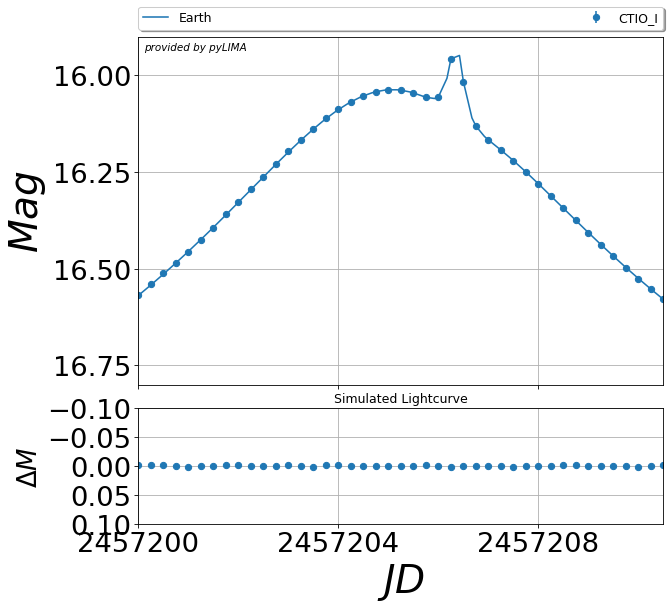

In [4]:
from pyLIMA.simulations import simulator

event_3 = event.Event(ra=270, dec=0)
event_3.name = 'My simulated event'

CTIO_I = simulator.simulate_a_telescope(name='CTIO_I', time_start=2457190, time_end=2457220, sampling=6, 
                                        location='Earth', camera_filter='I',
                                        uniform_sampling=True, astrometry=False)
# LCO_SAAO = simulator.simulate_a_telescope(name='LCO_SAAO', time_start=2457205, time_end=2457208, sampling=1, 
#                                         location='Earth', camera_filter='I',
#                                         uniform_sampling=True, astrometry=False)

event_3.telescopes.append(CTIO_I)
# event_3.telescopes.append(LCO_SAAO)
event_3.check_event()

psbl_sim = PSBL_model.PSBLmodel(event_3)
psbl_parameters = simulator.simulate_microlensing_model_parameters(psbl_sim)

### Set the parameters to some reasonable values.
psbl_parameters[0] = 2457205.21 # t0
psbl_parameters[1:3] = [0.309, 10.7821] # u0, tE
psbl_parameters[3:6] = [1.3, 0.001, 1.9] # s, q, alpha

### Set the source and blend fluxes of all telescopes to the same values for plotting purposes.
n_tel = len(event_3.telescopes)
psbl_parameters[-n_tel*2::2] = 10000. * np.ones(n_tel) # source fluxes
psbl_parameters[-n_tel*2+1::2] = 12000. * np.ones(n_tel) # total fluxes
print(psbl_parameters)

### Transform the parameters into a pyLIMA class object.
pyLIMA_parameters_1 = psbl_sim.compute_pyLIMA_parameters(psbl_parameters)

### Inject everthing into the simulator to produce a light curve.
simulator.simulate_lightcurve(psbl_sim, pyLIMA_parameters_1)

pyLIMA_plots.plot_lightcurves(psbl_sim, psbl_parameters)
plt.title('Simulated Lightcurve')
plt.gcf().axes[0].set_xlim(2457200.0, 2457210.5)
plt.gcf().axes[0].set_ylim(16.8, 15.9)
plt.show()

In [5]:
# Select event
my_event = event_3

Selecting CTIO_I to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2457205.25, 0.4744484519202907, 5.5, 18641.844393645824, 14325.594469032643]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2457205.19154516)),
             ('u0', np.float64(0.32168558509603223)),
             ('tE', np.float64(10.55459718057906)),
             ('fsource_CTIO_I', np.float64(10378.251598918761)),
             ('ftotal_CTIO_I', np.float64(12030.554318615707)),
             ('soft_l1', np.float64(713.0371985562864))])


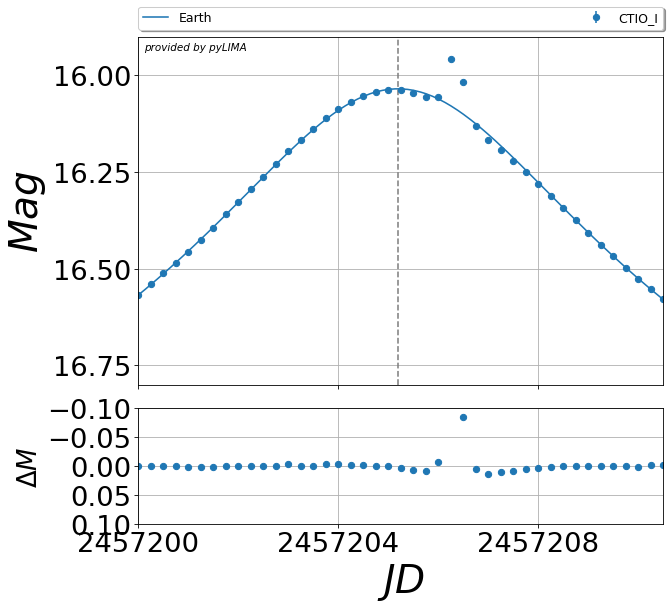

In [6]:
# PSPL model
pspl = PSPL_model.PSPLmodel(my_event)
# Robust fit
fit = TRF_fit.TRFfit(pspl, loss_function='soft_l1')
if my_event == event_1:
    fit.model_parameters_guess = [2457205.5, 1.0, 100.0]
fit.fit()
params =  OrderedDict(zip(fit.priors_parameters.keys(), fit.fit_results['best_model']))

# Plot
fig, _ = pyLIMA_plots.plot_lightcurves(pspl, fit.fit_results['best_model'])
# Set the window dimension.
if my_event == event_1:
    fig.axes[0].set_xlim(2457204.0, 2457206.5)
    fig.axes[0].set_ylim(15.50, 14.40)
if my_event == event_2:
    fig.axes[0].set_xlim(79.75, 80.25)
    fig.axes[0].set_ylim(14.50, 13.7)
if my_event == event_3:
    fig.axes[0].set_xlim(2457200.0, 2457210.5)
    fig.axes[0].set_ylim(16.8, 15.9)

# Line at t0
fig.axes[0].axvline(params['t0'], color='gray', linestyle='--')
plt.show()

In [7]:
import reldev_grid as rd

# assumptions
q = 0.001 
rs = 0.0005

# get parameters from pspl fit
# print(params)
t0 = params['t0']
u0 = params['u0']
te = params['tE']

# algorithm parameters
t_range = (t0 - 5, t0 + 5) # distance from t0 to compute reldev [in JD]

# Setup Meshgrid
x_min = -2.0, 
x_max = 2.0, 
y_min = -2.0, 
y_max = 2.0, 
resolution = 100
x_range = np.linspace(x_min, x_max, resolution)
y_range = np.linspace(y_min, y_max, resolution)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
Z_total = np.zeros_like(X_grid)

# Setup dict for saving values while running
reldev_maps = {}
reldev_maps['t'] = []
reldev_maps['name'] = []
reldev_maps['weight'] = []
reldev_maps['weighted_map'] = []

# running values
n_points = 0

# per telescope
for telescope in my_event.telescopes:

    name = telescope.name
    # telescope parameters from fit
    fs = params['fsource_' + name]
    fb = params['ftotal_' + name] - params['fsource_' + name] # unused

    # crop lightcurve to t_range
    time = telescope.lightcurve['time'].value
    lightcurve = telescope.lightcurve[(time > t_range[0]) & (time < t_range[1])]

    # per datapoint
    for datapoint in lightcurve:

        # parameters from datapoint
        t = datapoint['time'].value # in [JD]
        try:
            freal = datapoint['flux'].value
            ferr = datapoint['err_flux'].value # in [W/m^2]
        except:
            freal = datapoint['flux']
            ferr = datapoint['err_flux']

        # setup a vectorized function to compute reldev at each point
        def vectorized_reldev_wrapper(X_arr, Y_arr):
            vectorized_func = np.vectorize(lambda x, y: rd.reldev(q, t, u0, te, t0, fs, fb, ferr, rs, x, y))
            return vectorized_func(X_arr, Y_arr)
        
        # compute reldev values on meshgrid
        print(f'Running Grid Analysis for {name} at t={t}.')
        Z = vectorized_reldev_wrapper(X_grid, Y_grid)

        # compute weight by difference of pspl and real flux
        pspl = rd.pspl_n_imagesf(t, u0, te, t0)[0]
        fmodel = fs * pspl + fb
        weight = (freal - fmodel)**2 / ferr**2 # use delta chisq 
        print(freal, fmodel, weight)

        # save
        reldev_maps['t'].append(t)
        reldev_maps['name'].append(name)
        reldev_maps['weight'].append(weight)
        reldev_maps['weighted_map'].append(weight*Z)

# average the reldev maps
reldev_map_avg = np.average(reldev_maps['weighted_map'], axis=0)
unweighted_maps = np.array(reldev_maps['weighted_map']) / np.array(reldev_maps['weight'])[:, np.newaxis, np.newaxis]
detection_zone = np.average(unweighted_maps, axis=0)

Running Grid Analysis for CTIO_I at t=2457200.25.
22065.4 22062.61699189048 0.01757040591511618
Running Grid Analysis for CTIO_I at t=2457200.5.
22650.78 22638.58254698417 0.32892316403262317
Running Grid Analysis for CTIO_I at t=2457200.75.
23235.22 23249.507129609487 0.43940919739505063
Running Grid Analysis for CTIO_I at t=2457201.0.
23843.82 23896.409667649164 5.792142317117145
Running Grid Analysis for CTIO_I at t=2457201.25.
24542.58 24579.853918276465 2.8285832119296277
Running Grid Analysis for CTIO_I at t=2457201.5.
25261.54 25299.756112261486 2.8884807979401774
Running Grid Analysis for CTIO_I at t=2457201.75.
26063.16 26055.142429080814 0.12343143320599523
Running Grid Analysis for CTIO_I at t=2457202.0.
26857.88 26843.851093641857 0.3667433685087773
Running Grid Analysis for CTIO_I at t=2457202.25.
27665.28 27662.17840526603 0.017392161962842413
Running Grid Analysis for CTIO_I at t=2457202.5.
28525.64 28504.47650284748 0.7856460550738363
Running Grid Analysis for CTIO_I at

40 4 10


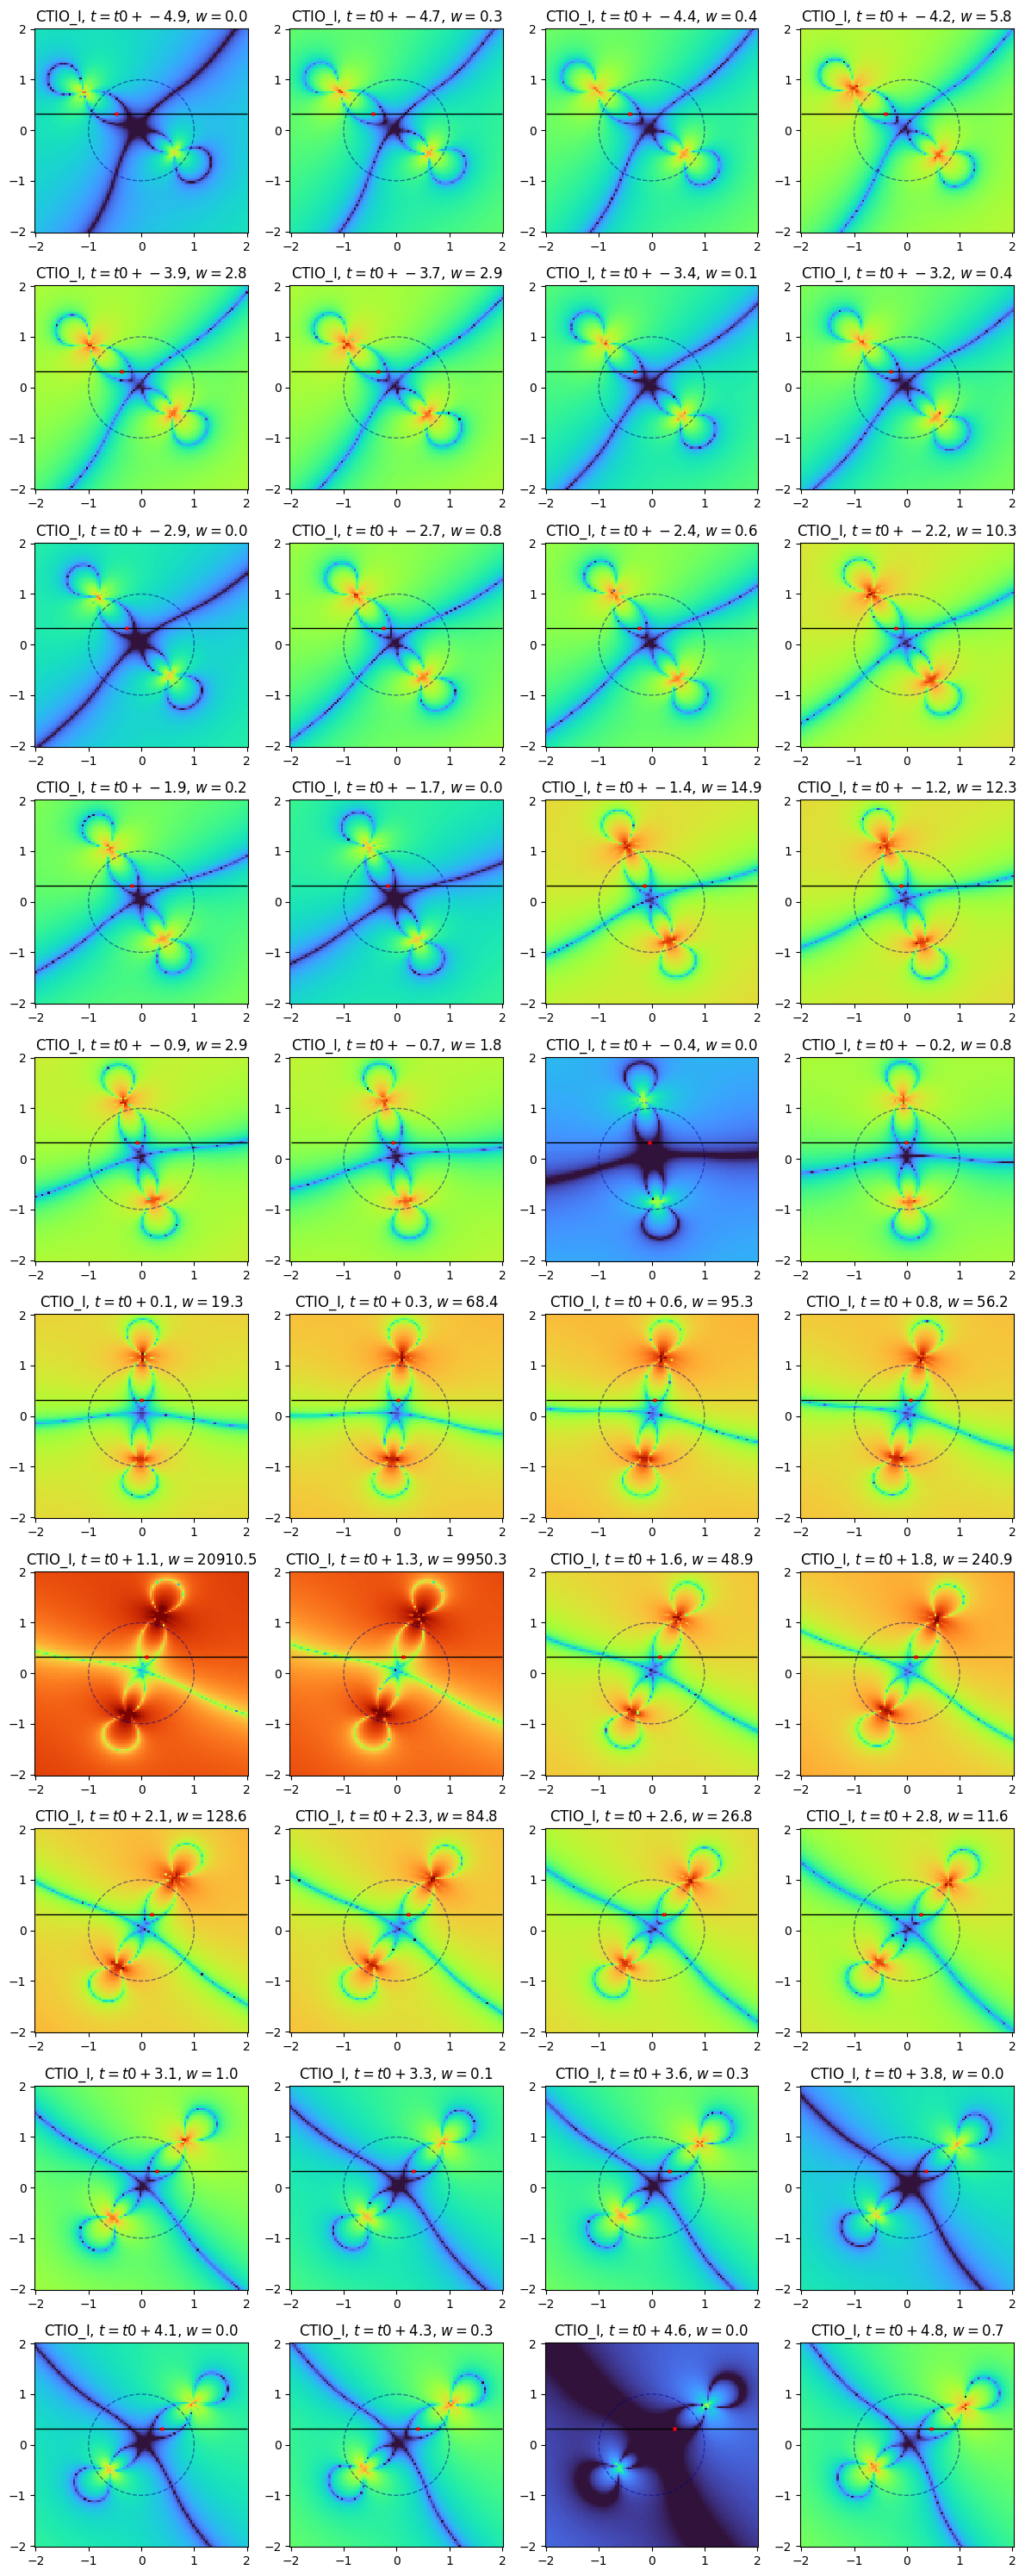

In [8]:
# Figure of all individual maps
import matplotlib.cm as cm
import matplotlib.colors as colors

n_maps = len(reldev_maps['weighted_map']) 
nx_maps = 4
ny_maps = math.ceil(n_maps/nx_maps)
print(n_maps, nx_maps, ny_maps)

plt.figure(figsize=(3*nx_maps, 3*ny_maps))
# plt.suptitle('Relative deviation caused by 2nd lens $\\log_{10}(\\Delta\\mu/\\mu$))')

for i in range(n_maps):
    # unpack
    name = reldev_maps['name'][i]
    t = reldev_maps['t'][i]
    map = reldev_maps['weighted_map'][i]
    weight = reldev_maps['weight'][i]

    # create subplot
    plt.subplot(ny_maps, nx_maps, i+1)
    plt.title(f'{name}, $t = t0 + {t - t0:.1f}$, $w = {weight:.1f}$')

    # heatmap
    norm = colors.LogNorm(1e-5, 1e8)
    plt.pcolormesh(X_grid, Y_grid, map, shading='auto', cmap=cm.turbo, norm=norm)

    # trajectory
    plt.hlines(u0, xmin=np.min(X_grid), xmax=np.max(X_grid), 
        linestyle='-', lw=1, color='k', label="Source Trajectory")
    plt.scatter((t - t0) / te, u0, 
                s=6, c='red', marker='x', label='Source Pos. at Obs.', zorder=2)
    
    # Einstein ring
    theta = np.linspace(0, 2 * np.pi, 100)
    x = 1 * np.cos(theta)
    y = 1 * np.sin(theta)
    plt.plot(x, y, linestyle='--', lw=1, alpha=0.5, color='darkblue', label="$\\theta_E$")

# show
plt.tight_layout()
plt.show()

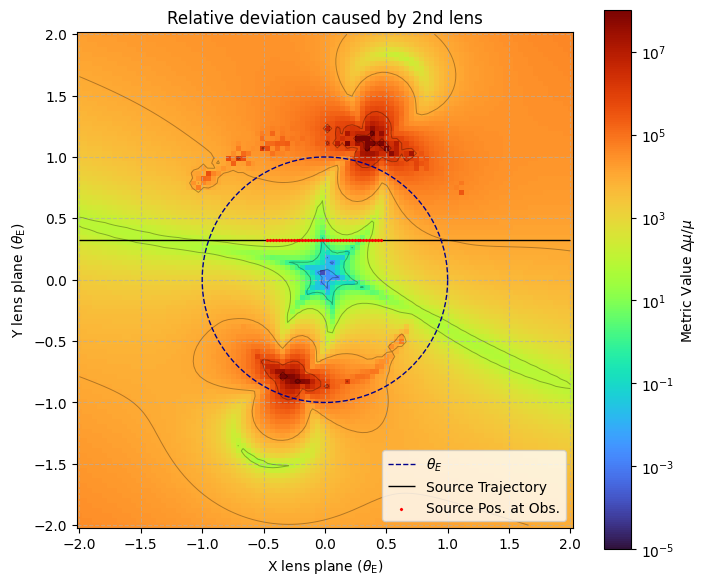

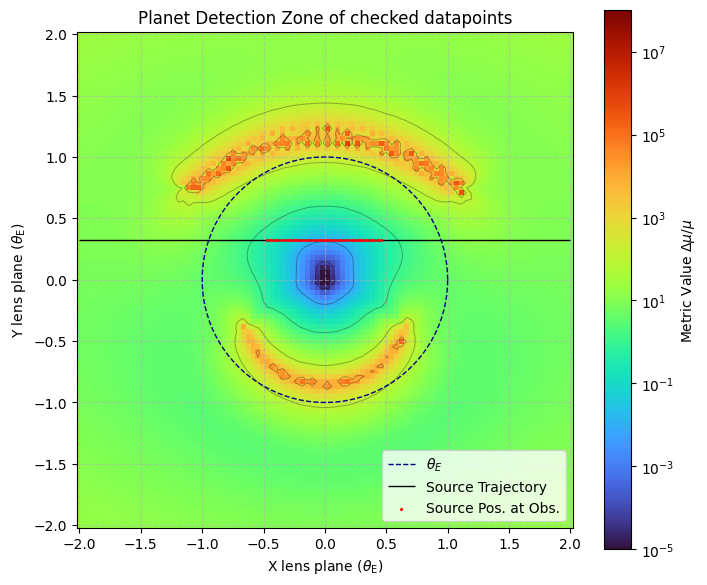

In [9]:
### Heatmap Plot
rd.plot_heatmap(X_grid, Y_grid, reldev_map_avg, 
                norm=colors.LogNorm(1e-5,1e8),
                add_cbar=True, add_contour=True, add_grid=True, add_tE=True,
                add_trajectory=True, t0=t0, u0=u0, te=te, t=reldev_maps['t'])

rd.plot_heatmap(X_grid, Y_grid, detection_zone, 
                norm=colors.LogNorm(1e-5,1e8),
                add_cbar=True, add_contour=True, add_grid=True, add_tE=True,
                add_trajectory=True, t0=t0, u0=u0, te=te, t=reldev_maps['t'],
                show_plot=False)
plt.title('Planet Detection Zone of checked datapoints')
plt.show()

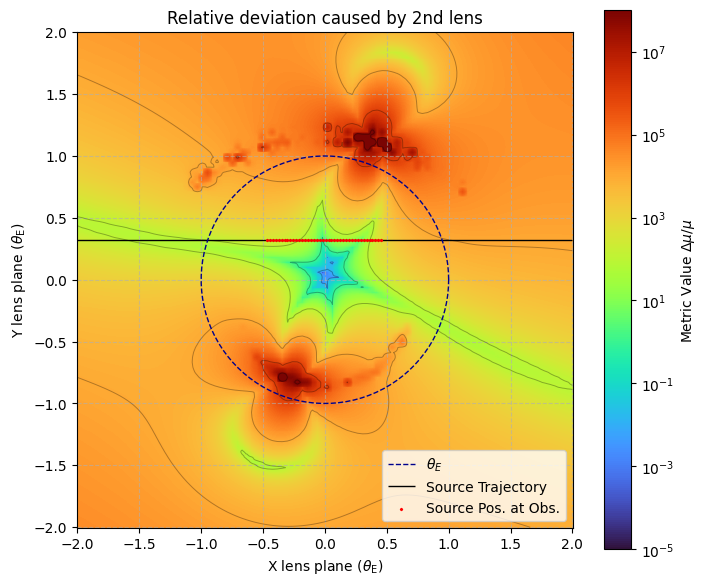

In [10]:
from scipy import interpolate

# Interpolate the grid 
resolution_interpol = 5
x_fine = np.linspace(x_min, x_max, resolution * resolution_interpol)
y_fine = np.linspace(y_min, y_max, resolution * resolution_interpol)   
X_f, Y_f = np.meshgrid(x_fine, y_fine)
interp_func = interpolate.RegularGridInterpolator((x_range.ravel(), y_range.ravel()), reldev_map_avg.T, method="linear")

# Plotting the result
points = np.array([X_f.ravel(), Y_f.ravel()]).T
Z_fine = interp_func(points).reshape(X_f.shape)
rd.plot_heatmap(X_f, Y_f, Z_fine, 
                norm=colors.LogNorm(1e-5,1e8),
                add_cbar=True, add_contour=True, add_grid=True, add_tE=True,
                add_trajectory=True, t0=t0, u0=u0, te=te, t=reldev_maps['t']
                )
